<h3>Second exercise</h3>

Simulate the cross-referencing of two distinct databases (for example, cross-referencing a Jungle Fitness inventory control spreadsheet with a monthly sales spreadsheet) to find inconsistencies.

In [1]:
import pandas as pd

# Base de Estoque
estoque_dados = {
    'ID_Produto': ['JF-001', 'JF-002', 'JF-003', 'JF-004', 'JF-005'],
    'Nome_Item': ['Whey Protein 1kg', 'Creatina 300g', 'BCAA Caps', 'Pre-Workout 200g', 'Albumina 500g'],
    'Qtd_Estoque': [50, 30, 100, 20, 45],
    'Preco_Custo': [120.00, 80.00, 45.00, 95.00, 35.00]
}

df_estoque = pd.DataFrame(estoque_dados)

In [2]:
# Base de Vendas
vendas_dados = {
    'ID_Venda': [101, 102, 103, 104, 105],
    'ID_Produto': ['JF-001', 'JF-002', 'JF-999', 'JF-004', 'JF-001'], # JF-999 é um erro proposital
    'Qtd_Vendida': [2, 1, 1, 3, 1],
    'Data_Venda': ['2024-03-01', '2024-03-02', '2024-03-02', '2024-03-03', '2024-03-04']
}

df_vendas = pd.DataFrame(vendas_dados)

In [17]:
merge = pd.merge(left=df_vendas, right=df_estoque, on='ID_Produto', how='outer', indicator=True)

In [27]:
merge[['Qtd_Vendida', 'Qtd_Estoque']] = merge[['Qtd_Vendida', 'Qtd_Estoque']].fillna(0)

In [30]:
merge

,ID_Venda,ID_Produto,Qtd_Vendida,Data_Venda,Nome_Item,Qtd_Estoque,Preco_Custo,_merge,Estoque_Final
0,101.0,JF-001,2,2024-03-01,Whey Protein 1kg,50.0,120.0,both,48.0
1,105.0,JF-001,1,2024-03-04,Whey Protein 1kg,50.0,120.0,both,49.0
2,102.0,JF-002,1,2024-03-02,Creatina 300g,30.0,80.0,both,29.0
3,NaN,JF-003,0,NaN,BCAA Caps,100.0,45.0,right_only,100.0
4,104.0,JF-004,3,2024-03-03,Pre-Workout 200g,20.0,95.0,both,17.0
5,NaN,JF-005,0,NaN,Albumina 500g,45.0,35.0,right_only,45.0
6,103.0,JF-999,1,2024-03-02,NaN,0.0,NaN,left_only,NaN


In [31]:
merge['Qtd_Vendida']= merge['Qtd_Vendida'].astype(int)
merge['Estoque_Final'] = merge['Qtd_Estoque'] - merge['Qtd_Vendida']

In [32]:
relatorio_erro = merge.query("_merge == 'right_only'")
relatorio_erro

,ID_Venda,ID_Produto,Qtd_Vendida,Data_Venda,Nome_Item,Qtd_Estoque,Preco_Custo,_merge,Estoque_Final
3,NaN,JF-003,0,NaN,BCAA Caps,100.0,45.0,right_only,100.0
5,NaN,JF-005,0,NaN,Albumina 500g,45.0,35.0,right_only,45.0


In [33]:
merge

,ID_Venda,ID_Produto,Qtd_Vendida,Data_Venda,Nome_Item,Qtd_Estoque,Preco_Custo,_merge,Estoque_Final
0,101.0,JF-001,2,2024-03-01,Whey Protein 1kg,50.0,120.0,both,48.0
1,105.0,JF-001,1,2024-03-04,Whey Protein 1kg,50.0,120.0,both,49.0
2,102.0,JF-002,1,2024-03-02,Creatina 300g,30.0,80.0,both,29.0
3,NaN,JF-003,0,NaN,BCAA Caps,100.0,45.0,right_only,100.0
4,104.0,JF-004,3,2024-03-03,Pre-Workout 200g,20.0,95.0,both,17.0
5,NaN,JF-005,0,NaN,Albumina 500g,45.0,35.0,right_only,45.0
6,103.0,JF-999,1,2024-03-02,NaN,0.0,NaN,left_only,-1.0


In [41]:
merge.to_csv('relatorio_conjunto_dfs.csv', sep=',', index=False)
merge.to_excel('relatorio_conjunto_dfs.xlsx', index=False)


In [42]:
pd.read_excel('relatorio_conjunto_dfs.xlsx')

,ID_Venda,ID_Produto,Qtd_Vendida,Data_Venda,Nome_Item,Qtd_Estoque,Preco_Custo,_merge,Estoque_Final
0,101.0,JF-001,2,2024-03-01,Whey Protein 1kg,50,120.0,both,48
1,105.0,JF-001,1,2024-03-04,Whey Protein 1kg,50,120.0,both,49
2,102.0,JF-002,1,2024-03-02,Creatina 300g,30,80.0,both,29
3,NaN,JF-003,0,NaN,BCAA Caps,100,45.0,right_only,100
4,104.0,JF-004,3,2024-03-03,Pre-Workout 200g,20,95.0,both,17
5,NaN,JF-005,0,NaN,Albumina 500g,45,35.0,right_only,45
6,103.0,JF-999,1,2024-03-02,NaN,0,NaN,left_only,-1


In [43]:
import matplotlib.pyplot as plt

In [44]:
df_grafico = merge.dropna(subset=['Nome_Item'])

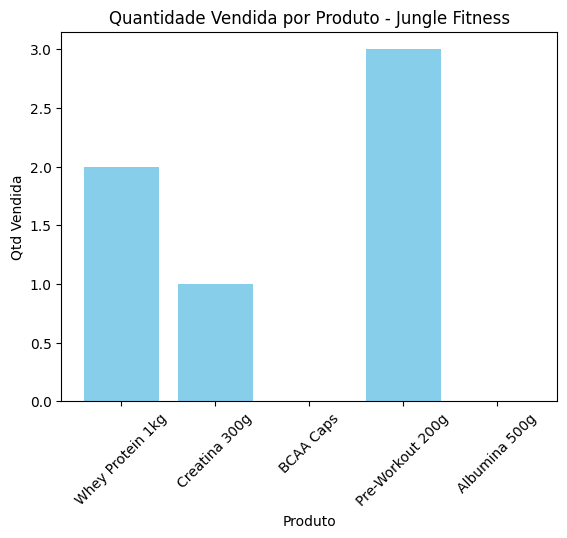

In [47]:
plt.bar(df_grafico['Nome_Item'], df_grafico['Qtd_Vendida'], color='skyblue')

plt.title('Quantidade Vendida por Produto - Jungle Fitness')
plt.xlabel('Produto')
plt.ylabel('Qtd Vendida')
plt.xticks(rotation=45)

plt.show()

In [48]:
merge

,ID_Venda,ID_Produto,Qtd_Vendida,Data_Venda,Nome_Item,Qtd_Estoque,Preco_Custo,_merge,Estoque_Final
0,101.0,JF-001,2,2024-03-01,Whey Protein 1kg,50.0,120.0,both,48.0
1,105.0,JF-001,1,2024-03-04,Whey Protein 1kg,50.0,120.0,both,49.0
2,102.0,JF-002,1,2024-03-02,Creatina 300g,30.0,80.0,both,29.0
3,NaN,JF-003,0,NaN,BCAA Caps,100.0,45.0,right_only,100.0
4,104.0,JF-004,3,2024-03-03,Pre-Workout 200g,20.0,95.0,both,17.0
5,NaN,JF-005,0,NaN,Albumina 500g,45.0,35.0,right_only,45.0
6,103.0,JF-999,1,2024-03-02,NaN,0.0,NaN,left_only,-1.0


In [62]:
merge['Data_Venda'] = pd.to_datetime(merge['Data_Venda'])

data_nova = pd.to_datetime('1900-02-10')

merge.loc[3, 'Data_Venda'] = data_nova
merge.loc[5, 'Data_Venda'] = data_nova


In [64]:
merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID_Venda       5 non-null      float64       
 1   ID_Produto     7 non-null      str           
 2   Qtd_Vendida    7 non-null      int64         
 3   Data_Venda     7 non-null      datetime64[us]
 4   Nome_Item      6 non-null      str           
 5   Qtd_Estoque    7 non-null      float64       
 6   Preco_Custo    6 non-null      float64       
 7   _merge         7 non-null      category      
 8   Estoque_Final  7 non-null      float64       
dtypes: category(1), datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 719.0 bytes
